In [3]:
# PROGRAM 1: Automatic Headlight Control System

import cv2
import numpy as np

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained CNN
model = MobileNetV2(weights="imagenet")

# Read an image (camera sensor simulation)
image = cv2.imread("day.jpg")

# Check if image was loaded
if image is None:
    print("Image not found")
    exit()

# Resize image for CNN
img = cv2.resize(image, (224, 224))

# Prepare image for CNN
x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

# CNN Prediction
predictions = model.predict(x, verbose=0)

print("CNN Prediction:")
print(decode_predictions(predictions, top=3)[0])

# Calculate ambient brightness
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
brightness = np.mean(gray)

print("Ambient Brightness:", brightness)

# Automatic Headlight Control
if brightness < 80:
    print("Headlights ON")
else:
    print("Headlights OFF")

CNN Prediction:
[('n04482393', 'tricycle', np.float32(0.12121512)), ('n03444034', 'go-kart', np.float32(0.059264287)), ('n03891251', 'park_bench', np.float32(0.042795822))]
Ambient Brightness: 143.84884640738298
Headlights OFF


In [ ]:
# PROGRAM 2: Parking Assistance System

import cv2
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Load parking image
image = cv2.imread("parking.jpg")

# Check if image was loaded
if image is None:
    print("Image not found")
    exit()

# Run object detection
results = model(image)

# Copy image
output = image.copy()

for result in results:

    boxes = result.boxes

    for box in boxes:

        # Bounding box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Confidence
        confidence = float(box.conf[0])

        # Class ID
        class_id = int(box.cls[0])

        # Class name
        label = model.names[class_id]

        # Width and Height
        width = x2 - x1
        height = y2 - y1

        # Bounding box area
        area = width * height

        # Estimate distance using bounding box area
        if area > 120000:
            warning = "STOP!"
            color = (0, 0, 255)

        elif area > 60000:
            warning = "BRAKE NOW"
            color = (0, 140, 255)

        elif area > 25000:
            warning = "SLOW DOWN"
            color = (0, 255, 255)

        else:
            warning = "SAFE"
            color = (0, 255, 0)

        # Draw bounding box
        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        # Object name and confidence
        cv2.putText(
            output,
            f"{label} {confidence:.2f}",
            (x1, y1 - 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

        # Warning message
        cv2.putText(
            output,
            warning,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

# Display output
cv2.imshow("Parking Assistance System", output)

cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 1 cell phone, 247.7ms
Speed: 8.7ms preprocess, 247.7ms inference, 16.4ms postprocess per image at shape (1, 3, 480, 640)


In [ ]:
# PROGRAM 3: Write a program to implement a Forward Collision Warning System that alerts the driver when the distance to the vehicle ahead becomes unsafe. 
from ultralytics import YOLO
import cv2
import time

model = YOLO("yolov8n.pt")
cap = cv2.VideoCapture("test.mp4")

FOCAL_LENGTH = 700
KNOWN_WIDTH = 1.8
previous_distance = None
previous_time = None
smoothed_ttc = None

def estimate_distance(box_width):
    box_width = max(box_width, 1)
    return (KNOWN_WIDTH * FOCAL_LENGTH) / box_width

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_time = time.time()
    results = model(frame, verbose=False)[0]

    best_distance = None
    best_box = None

    for box in results.boxes:
        name = model.names[int(box.cls[0])]
        if name not in ["car", "truck", "bus", "motorcycle"]:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        width = x2 - x1
        distance = estimate_distance(width)

        # Choose the closest vehicle
        if best_distance is None or distance < best_distance:
            best_distance = distance
            best_box = (x1, y1, x2, y2)

    ttc = float("inf")

    if best_distance is not None:
        if previous_distance is not None and previous_time is not None:
            dt = max(current_time - previous_time, 1e-3)

            # Positive relative speed means the gap is closing
            relative_speed = (previous_distance - best_distance) / dt

            if relative_speed > 0.1:
                ttc = best_distance / relative_speed

                # Simple temporal smoothing
                if smoothed_ttc is None:
                    smoothed_ttc = ttc
                else:
                    smoothed_ttc = 0.7 * smoothed_ttc + 0.3 * ttc

        previous_distance = best_distance
        previous_time = current_time

        if best_box:
            x1, y1, x2, y2 = best_box
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,255), 2)
            cv2.putText(frame, f"Distance: {best_distance:.1f} m",
                        (x1, max(y1-10,20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)

    displayed_ttc = smoothed_ttc if smoothed_ttc is not None else float("inf")

    if displayed_ttc < 2:
        warning = "CRITICAL: COLLISION WARNING!"
    elif displayed_ttc < 4:
        warning = "CAUTION: REDUCE SPEED"
    else:
        warning = "SAFE"

    cv2.putText(frame, warning, (25,45),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                (0,0,255) if "CRITICAL" in warning else
                (0,165,255) if "CAUTION" in warning else (0,255,0), 3)

    cv2.putText(frame, f"TTC: {displayed_ttc:.2f} s",
                (25,85), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (255,255,255), 2)

    cv2.imshow("Forward Collision Warning", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


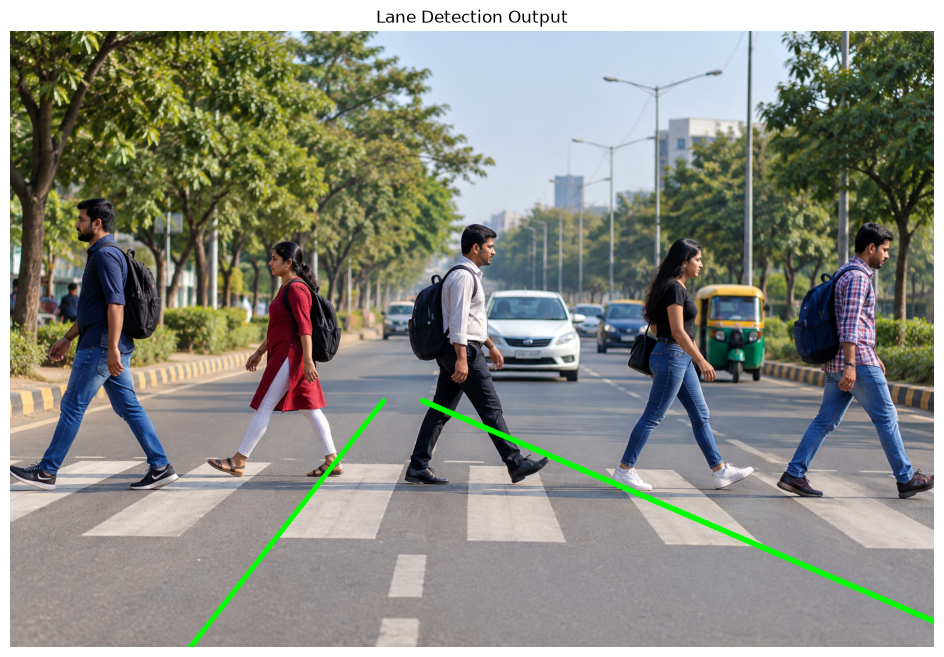

In [10]:
# PROGRAM 4: Lane Detection – OpenCV Canny + ROI + Hough Transform

import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("road.jpg")
if image is None:
    raise FileNotFoundError("road.jpg not found")

output = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)
h, w = edges.shape
mask = np.zeros_like(edges)

polygon = np.array([[
    (0, h),
    (w, h),
    (int(0.58 * w), int(0.58 * h)),
    (int(0.42 * w), int(0.58 * h))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)
roi_edges = cv2.bitwise_and(edges, mask)

# HOUGH TRANSFORM

lines = cv2.HoughLinesP(
    roi_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=30,
    maxLineGap=100
)

left_lines = []
right_lines = []

if lines is not None:

    # Makes line format consistently:
    # [x1, y1, x2, y2]
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        # Avoid division by zero
        if x2 == x1:
            continue

        # Calculate slope
        slope = (y2 - y1) / (x2 - x1)

        # Negative slope = left lane
        if -1.5 < slope < -0.4:
            left_lines.append((x1, y1, x2, y2))

        # Positive slope = right lane
        elif 0.4 < slope < 1.5:
            right_lines.append((x1, y1, x2, y2))

def average_line(lines, y_bottom, y_top):

    if len(lines) == 0:
        return None

    xs = []
    ys = []

    for x1, y1, x2, y2 in lines:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    # Fit line: y = slope*x + intercept
    slope, intercept = np.polyfit(xs, ys, 1)

    if abs(slope) < 1e-6:
        return None

    x_bottom = int((y_bottom - intercept) / slope)
    x_top = int((y_top - intercept) / slope)

    return x_bottom, y_bottom, x_top, y_top

y_bottom = h - 1
y_top = int(0.60 * h)

left_lane = average_line(left_lines, y_bottom, y_top)
right_lane = average_line(right_lines, y_bottom, y_top)

if left_lane is not None:
    x1, y1, x2, y2 = left_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

if right_lane is not None:
    x1, y1, x2, y2 = right_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title("Lane Detection Output")
plt.axis("off")
plt.show()

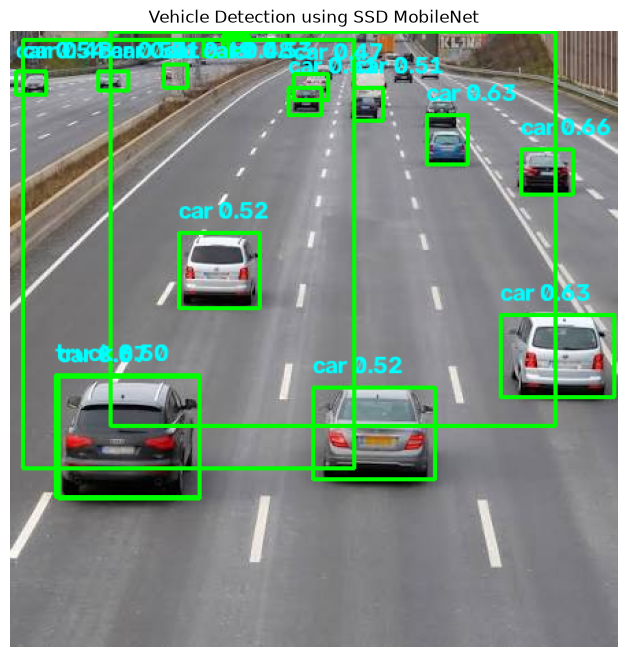

In [14]:
# PROGRAM 5: Write a program using OpenCV to detect vehicles in a road image and draw bounding boxes 
#around the detected vehicles. 
#Vehicle Detection – OpenCV DNN with SSD MobileNet

import cv2
import numpy as np
import matplotlib.pyplot as plt

CONFIG = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
WEIGHTS = "frozen_inference_graph.pb"

net = cv2.dnn_DetectionModel(WEIGHTS, CONFIG)

net.setInputSize(320, 320)
net.setInputScale(1.0 / 127.5)
net.setInputMean((127.5, 127.5, 127.5))
net.setInputSwapRB(True)

classNames = [
    "background","person","bicycle","car","motorcycle","airplane","bus",
    "train","truck","boat","traffic light","fire hydrant","stop sign",
    "parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag",
    "tie","suitcase","frisbee","skis","snowboard","sports ball","kite",
    "baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana",
    "apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","dining table",
    "toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock",
    "vase","scissors","teddy bear","hair drier","toothbrush"
]

image = cv2.imread("vehicle.jpg")

if image is None:
    raise FileNotFoundError("road.jpg not found")

output = image.copy()

classIds, scores, boxes = net.detect(
    image,
    confThreshold=0.45,
    nmsThreshold=0.40
)

classIds = np.array(classIds).flatten()
scores = np.array(scores).flatten()

vehicle_names = {"car", "motorcycle", "bus", "truck"}

for classId, score, box in zip(classIds, scores, boxes):

    classId = int(classId)

    # Safety check
    if classId >= len(classNames):
        continue

    name = classNames[classId]

    if name in vehicle_names:

        x, y, w, h = box

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"{name} {score:.2f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 0),
            2
        )

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title("Vehicle Detection using SSD MobileNet")
plt.axis("off")
plt.show()

In [22]:
#PROGRAM: 6 Write a program using image processing techniques to detect traffic signs based on their color 
#from an input image. 

import cv2
import numpy as np

image = cv2.imread("traffic_signs.jpg")
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# HSV ranges for common sign colors
red1 = cv2.inRange(hsv, (0,80,80), (10,255,255))
red2 = cv2.inRange(hsv, (170,80,80), (180,255,255))
red = red1 | red2

blue = cv2.inRange(hsv, (90,80,70), (130,255,255))
yellow = cv2.inRange(hsv, (18,80,80), (40,255,255))

combined = red | blue | yellow

kernel = np.ones((5,5), np.uint8)
combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel)
combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 150:
        continue

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue

    circularity = 4*np.pi*area/(perimeter*perimeter)

    if circularity > 0.35:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(image, "Traffic Sign",
                    (x,y-8), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0,255,255), 2)

cv2.imshow("Color Based Traffic Sign Detection", image)
cv2.waitKey(0)
cv2.destroyAllWindows()
